# Cookie Cats: first look at the data

Poking at the dataset before running the formal test in `src/ab_test.py`.
Checking group sizes, the gamerounds distribution, and whether anything
looks off before trusting the retention numbers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cookie_cats.csv")
print(df.shape)
df.head()

(90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [2]:
# group sizes - not perfectly 50/50, worth checking formally (SRM check is in src/ab_test.py)
df.version.value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [3]:
df.sum_gamerounds.describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Max is 49,854 rounds in 14 days. That's ~2,400 rounds a day, every day.
Not a human. Everyone else tops out around 3k.

In [4]:
df.sum_gamerounds.nlargest(5)

57702    49854
7912      2961
29417     2640
43671     2438
48188     2294
Name: sum_gamerounds, dtype: int64

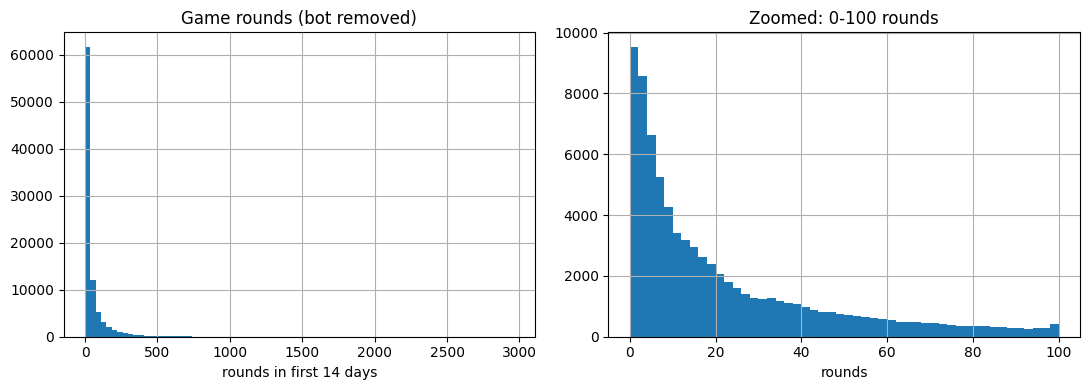

In [5]:
# distribution is heavily right skewed even after dropping the bot
clean = df[df.sum_gamerounds < 3000]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
clean.sum_gamerounds.hist(bins=80, ax=ax[0])
ax[0].set_title("Game rounds (bot removed)")
ax[0].set_xlabel("rounds in first 14 days")

clean[clean.sum_gamerounds <= 100].sum_gamerounds.hist(bins=50, ax=ax[1])
ax[1].set_title("Zoomed: 0-100 rounds")
ax[1].set_xlabel("rounds")
plt.tight_layout()

In [6]:
# how many players never really played?
(df.sum_gamerounds == 0).mean()

np.float64(0.0442847797403231)

About 4% installed and never played a round. They can't have hit either
gate, so in theory they dilute both groups equally - but it's worth knowing
they're in the denominator.

In [7]:
# retention rates by group, eyeballing before the formal test
df.groupby("version")[["retention_1", "retention_7"]].mean().round(4)

,retention_1,retention_7
version,,
gate_30,0.4482,0.1902
gate_40,0.4423,0.1820


,retention_1,retention_7
rounds_bin,,
1-5,0.077,0.014
6-20,0.309,0.049
21-50,0.637,0.153
51-100,0.804,0.356
101-500,0.894,0.695
500+,0.975,0.956


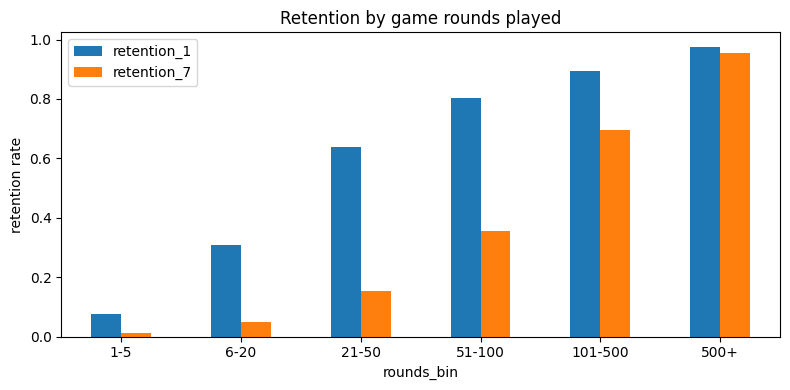

In [8]:
# retention by engagement level - unsurprisingly, people who play more come back more
clean["rounds_bin"] = pd.cut(clean.sum_gamerounds,
                             [0, 5, 20, 50, 100, 500, 3000],
                             labels=["1-5", "6-20", "21-50", "51-100", "101-500", "500+"])
ret = clean[clean.sum_gamerounds > 0].groupby("rounds_bin", observed=True)[["retention_1", "retention_7"]].mean()

ret.plot(kind="bar", figsize=(8, 4))
plt.ylabel("retention rate")
plt.title("Retention by game rounds played")
plt.xticks(rotation=0)
plt.tight_layout()
ret.round(3)

Takeaways:

- one obvious bot account to exclude (49,854 rounds)
- groups are close to balanced but not exactly - formal SRM check lives in `src/ab_test.py`
- raw retention rates already hint gate_40 is slightly worse on both metrics; the z-test in `src/ab_test.py` confirms the 7-day gap is real
- engagement and retention are tightly linked, which is why gamerounds would make a good CUPED covariate if we had a pre-period